In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import *
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## Загрузка данных

In [2]:
dataset_raw = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset_raw = dataset_raw.drop([0, 1, 2, 3, 504], axis=1)
dataset_raw.columns = list(range(500))
dataset_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [3]:
dataset_raw.shape

(23479, 500)

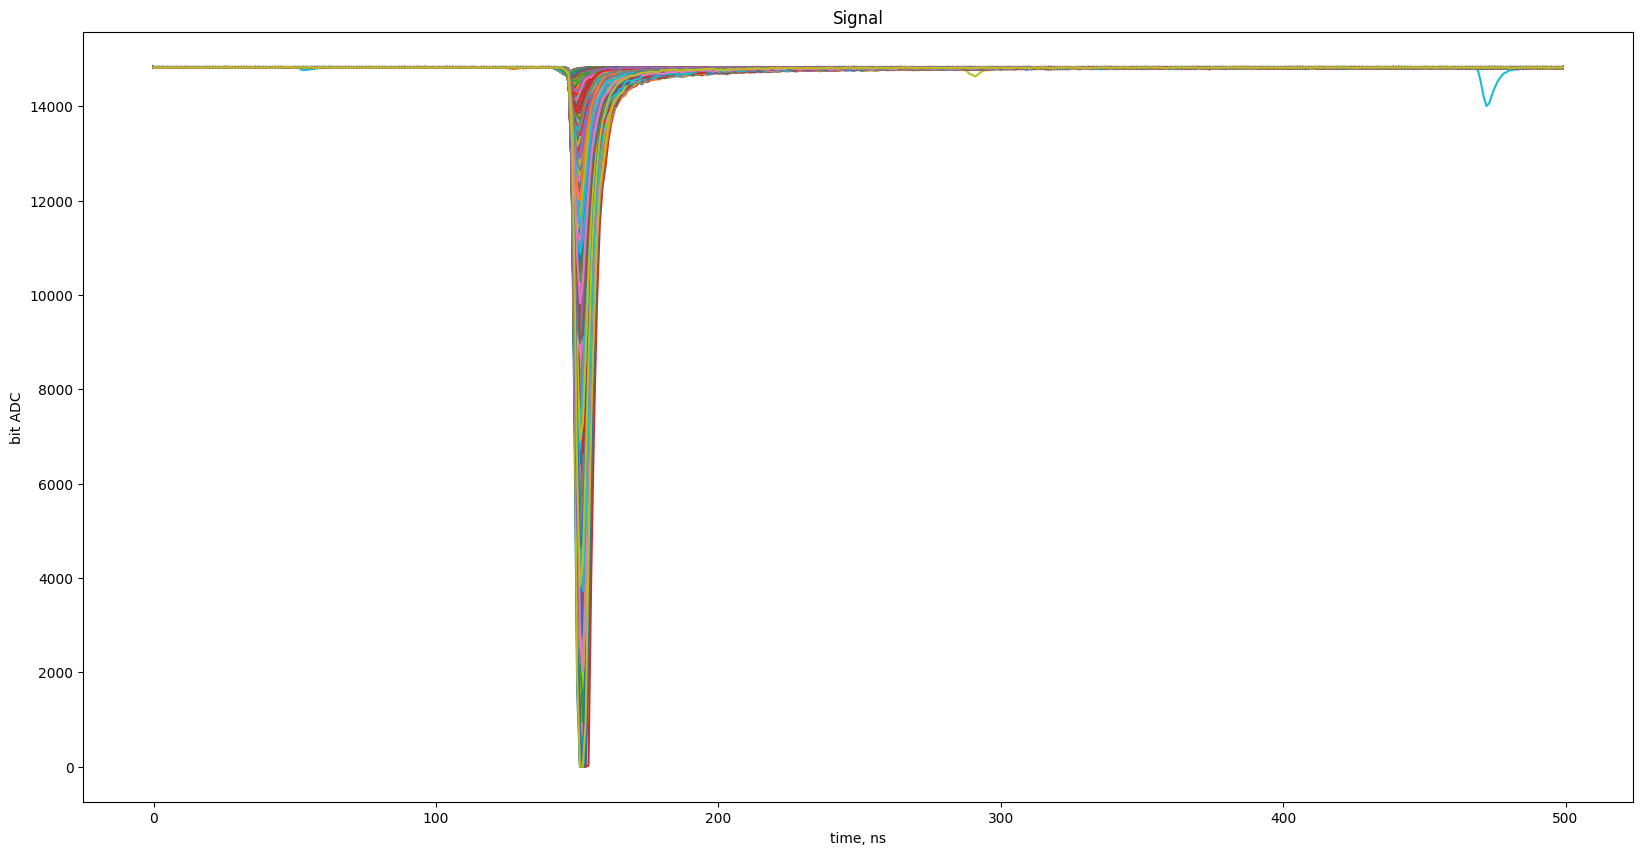

In [4]:
ax = dataset_raw.loc[:].T.plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

## Подготовка данных

"Переворачиваю" импульсы

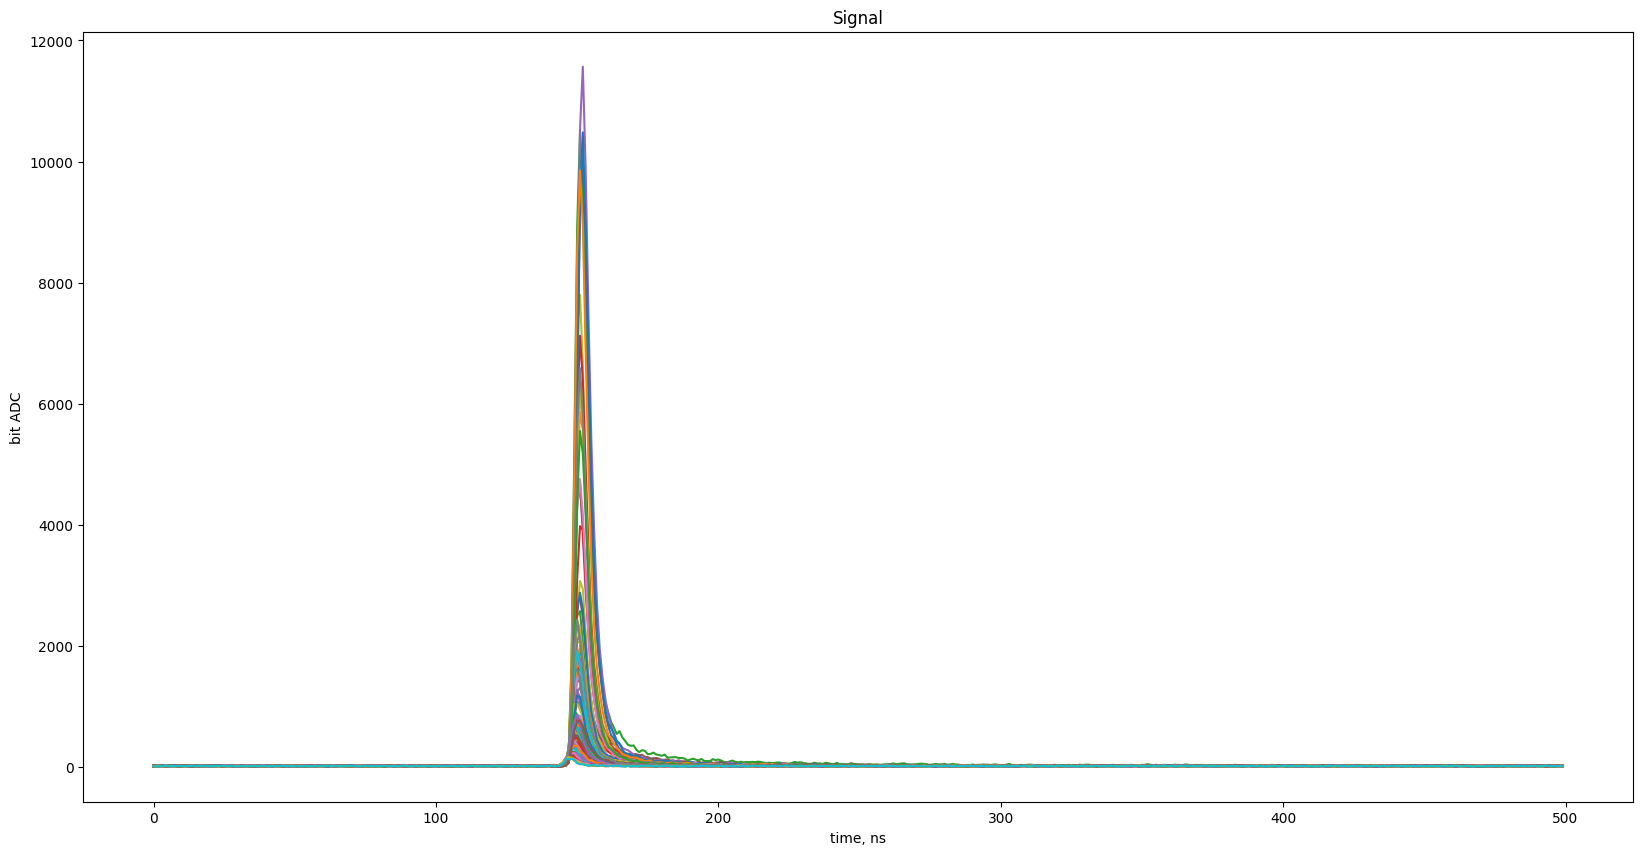

In [5]:
max_val = dataset_raw.max().max()
dataset_inverted = (dataset_raw * -1) + max_val
ax = dataset_inverted.loc[:].T[range(100)].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

## Генерация признаков (получение ширины и высоты пика)

<Axes: >

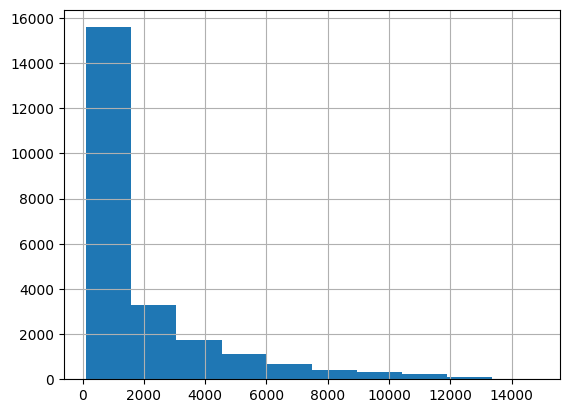

In [6]:
max_val_col = dataset_inverted.max(axis=1)
max_val_col.hist()

In [7]:
max_val_col.describe()

count    23479.000000
mean      1850.138209
std       2389.308983
min        119.000000
25%        323.000000
50%        828.000000
75%       2330.000000
max      14838.000000
dtype: float64

Выделяю пик: все, что выше 100

In [8]:
dataset_rolling = dataset_inverted.T.rolling(10).mean().T.loc[:, 140:].round()

In [9]:
peak_width = ((dataset_rolling.T - 100).T > 0).sum(axis=1)

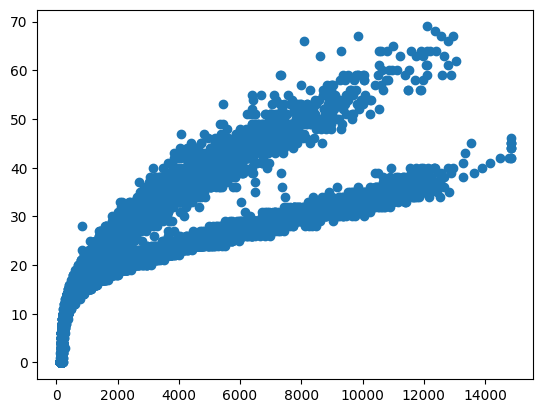

In [10]:
plt.scatter(max_val_col, peak_width)

In [11]:
data_final = pd.DataFrame([max_val_col, peak_width]).T

In [55]:
std_scaler = MinMaxScaler()
data = pd.DataFrame(std_scaler.fit_transform(data_final))
data.columns = ["peak_height", "peak_width"]

## KMeans

In [56]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data)
clustered_data = data.copy()
clustered_data["label"] = kmeans.labels_

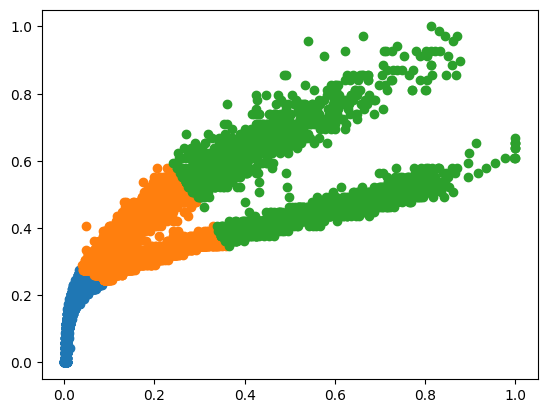

In [57]:
for i in range(3):
    cluster = clustered_data[clustered_data["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.show()

## DBSCAN

Cluster -1 count: 54
Cluster 0 count: 23425
Cluster 1 count: 0
Cluster 2 count: 0
Cluster 3 count: 0
Cluster 4 count: 0
Cluster 5 count: 0


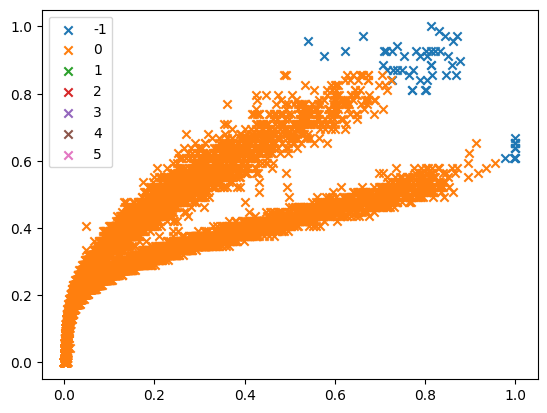

In [68]:
dbscan = DBSCAN(min_samples=100, eps=0.1, n_jobs=-1)
dbscan.fit(data)
clustered_data = data.copy()
clustered_data["label"] = dbscan.labels_

for i in range(-1, 6):
    cluster = clustered_data[clustered_data["label"] == i]
    print(f"Cluster {i} count: {len(cluster)}")
    plt.scatter(cluster["peak_height"], cluster["peak_width"], label=i, marker='x')
plt.legend()
plt.show()

In [ ]:
df0 = pd.DataFrame(pd.Series(kmeans.labels_), columns=["label"])
df0['cluster'] = -1
i = 0
for lbl in pd.Series(kmeans.labels_).unique():
    df0.loc[df0['label'] == lbl, 'cluster'] = i
    i += 1
df0.index.name = 'index'
df0["cluster"].to_csv(f"kmeans_result_max_plus.csv")